In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("twitter_training.csv")

In [ ]:
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [ ]:
df.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [ ]:
df.shape

(74681, 4)

In [ ]:
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [ ]:
df.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [ ]:
df.shape

(74681, 4)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [ ]:
df = pd.read_csv("twitter_training.csv", header=None)

In [ ]:
df.columns = ["ID", "Entity", "Sentiment", "Text"]

In [ ]:
df.head()

,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [ ]:
df.isnull().sum()

,0
ID,0
Entity,0
Sentiment,0
Text,686


In [ ]:
df = df.dropna(subset=["Text"])

In [ ]:
df.isnull().sum()

,0
ID,0
Entity,0
Sentiment,0
Text,0


In [ ]:
df["Sentiment"].value_counts()

,count
Sentiment,
Negative,22358
Positive,20655
Neutral,18108
Irrelevant,12875


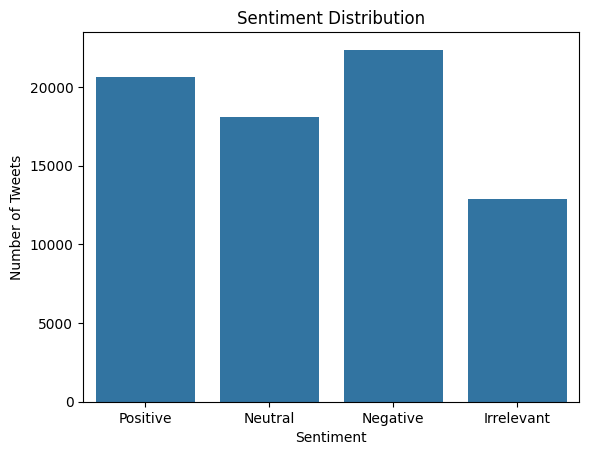

In [ ]:
sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

In [ ]:
df["Entity"].value_counts().head(10)

,count
Entity,
LeagueOfLegends,2377
MaddenNFL,2377
CallOfDuty,2376
Verizon,2365
TomClancysRainbowSix,2364
Facebook,2362
Microsoft,2361
Dota2,2359
WorldOfCraft,2357


In [ ]:
pd.crosstab(df["Entity"], df["Sentiment"])

Sentiment,Irrelevant,Negative,Neutral,Positive
Entity,,,,
Amazon,186,575,1207,308
ApexLegends,192,591,936,634
AssassinsCreed,264,375,156,1439
Battlefield,915,464,351,586
Borderlands,240,426,597,1017
CS-GO,632,344,548,760
CallOfDuty,672,883,375,446
CallOfDutyBlackopsColdWar,569,566,352,856
Cyberpunk2077,465,385,462,950


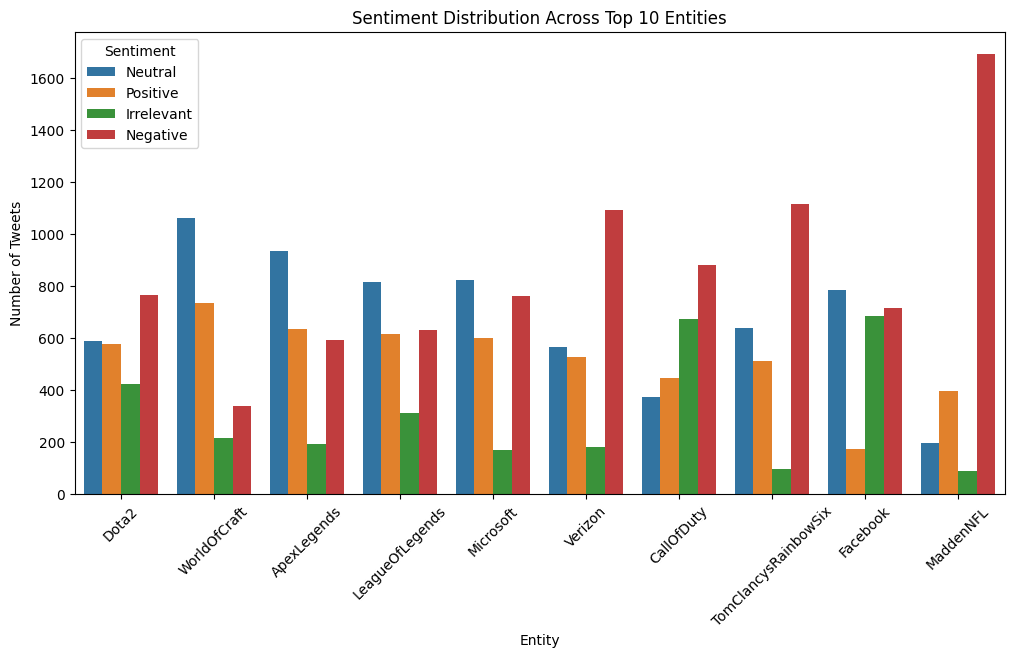

In [ ]:
top_entities = df["Entity"].value_counts().head(10).index

top_df = df[df["Entity"].isin(top_entities)]

plt.figure(figsize=(12, 6))

sns.countplot(
    data=top_df,
    x="Entity",
    hue="Sentiment"
)

plt.title("Sentiment Distribution Across Top 10 Entities")
plt.xlabel("Entity")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.show()

“The visualization shows that sentiment varies considerably across different entities. Some topics such as MaddenNFL and Verizon have a higher proportion of negative opinions, while entities such as Dota2 and WorldOfCraft show comparatively more neutral opinions.”

In [ ]:
sentiment_table = pd.crosstab(df["Entity"], df["Sentiment"])

print("Most Positive Entities:")
print(sentiment_table["Positive"].sort_values(ascending=False).head(10))

print("\nMost Negative Entities:")
print(sentiment_table["Negative"].sort_values(ascending=False).head(10))

Most Positive Entities:
Entity
AssassinsCreed               1439
Borderlands                  1017
Cyberpunk2077                 950
PlayStation5(PS5)             936
RedDeadRedemption(RDR)        927
CallOfDutyBlackopsColdWar     856
Hearthstone                   833
Nvidia                        802
Xbox(Xseries)                 785
HomeDepot                     772
Name: Positive, dtype: int64

Most Negative Entities:
Entity
MaddenNFL               1694
NBA2K                   1469
FIFA                    1169
TomClancysRainbowSix    1115
Verizon                 1092
TomClancysGhostRecon     894
HomeDepot                892
CallOfDuty               883
johnson&johnson          845
Dota2                    767
Name: Negative, dtype: int64


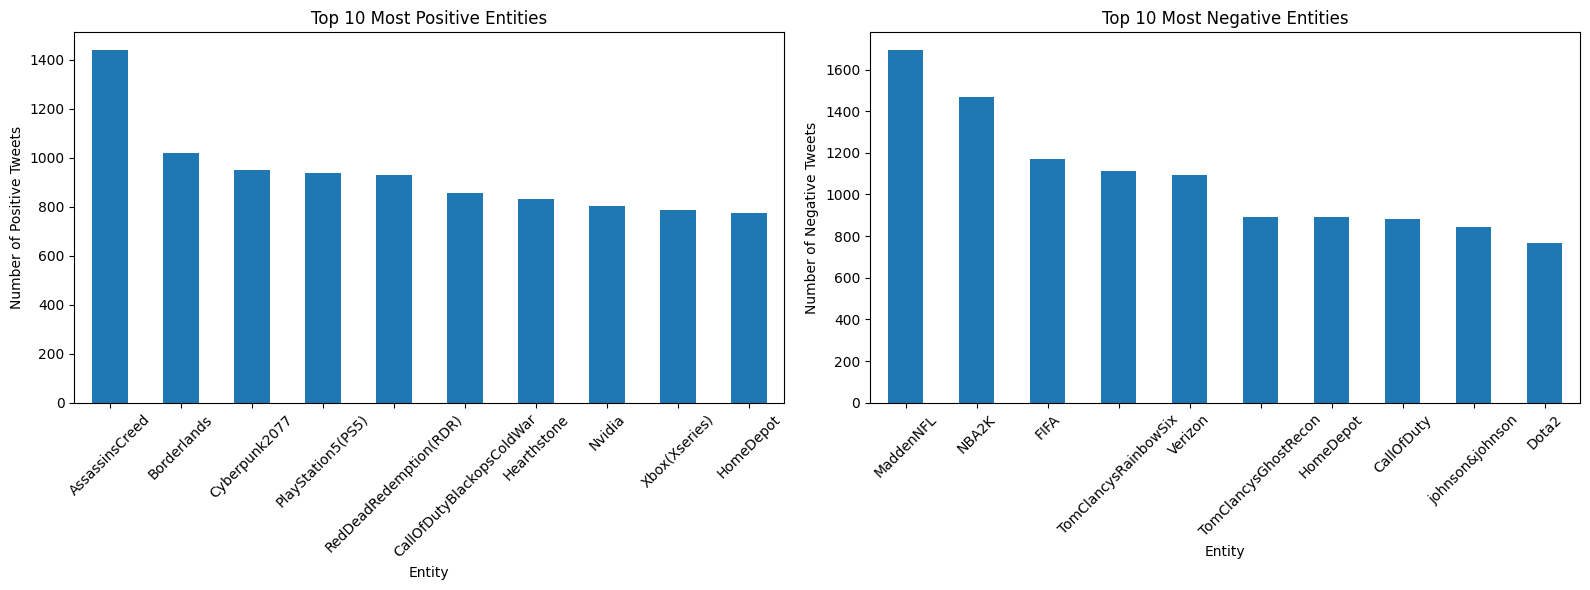

In [ ]:
positive = sentiment_table["Positive"].sort_values(ascending=False).head(10)
negative = sentiment_table["Negative"].sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

positive.plot(kind="bar", ax=axes[0])
axes[0].set_title("Top 10 Most Positive Entities")
axes[0].set_xlabel("Entity")
axes[0].set_ylabel("Number of Positive Tweets")
axes[0].tick_params(axis="x", rotation=45)

negative.plot(kind="bar", ax=axes[1])
axes[1].set_title("Top 10 Most Negative Entities")
axes[1].set_xlabel("Entity")
axes[1].set_ylabel("Number of Negative Tweets")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
sentiment_percentage = pd.crosstab(
    df["Entity"],
    df["Sentiment"],
    normalize="index"
) * 100

sentiment_percentage.head()

Sentiment,Irrelevant,Negative,Neutral,Positive
Entity,,,,
Amazon,8.172232,25.263620,53.031634,13.532513
ApexLegends,8.159796,25.116872,39.779006,26.944326
AssassinsCreed,11.817368,16.786034,6.982990,64.413608
Battlefield,39.507772,20.034542,15.155440,25.302245
Borderlands,10.526316,18.684211,26.184211,44.605263


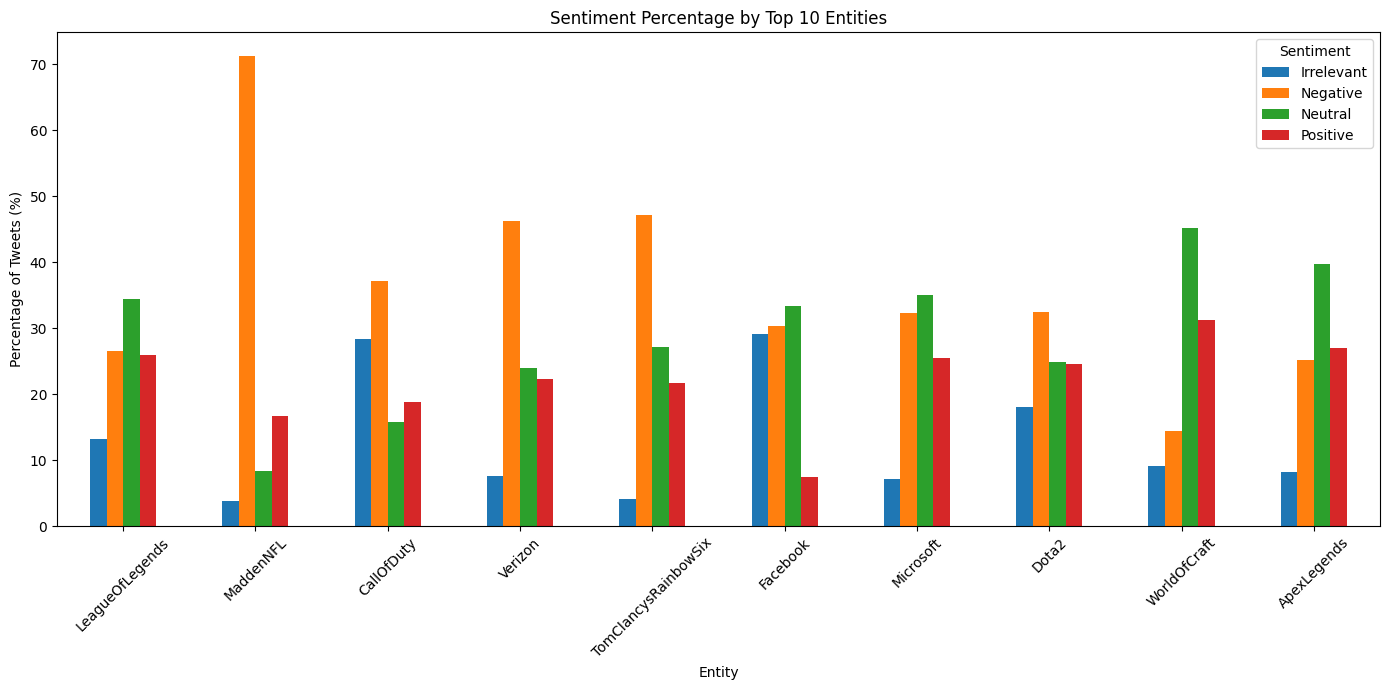

In [ ]:
top_entities = df["Entity"].value_counts().head(10).index

percentage_top = sentiment_percentage.loc[top_entities]

percentage_top.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Sentiment Percentage by Top 10 Entities")
plt.xlabel("Entity")
plt.ylabel("Percentage of Tweets (%)")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [ ]:
most_positive = sentiment_percentage["Positive"].idxmax()
positive_percentage = sentiment_percentage["Positive"].max()

print("Most Positive Entity:", most_positive)
print("Positive Percentage:", round(positive_percentage, 2), "%")

Most Positive Entity: AssassinsCreed
Positive Percentage: 64.41 %


In [ ]:
most_negative = sentiment_percentage["Negative"].idxmax()
negative_percentage = sentiment_percentage["Negative"].max()

print("Most Negative Entity:", most_negative)
print("Negative Percentage:", round(negative_percentage, 2), "%")

Most Negative Entity: MaddenNFL
Negative Percentage: 71.27 %


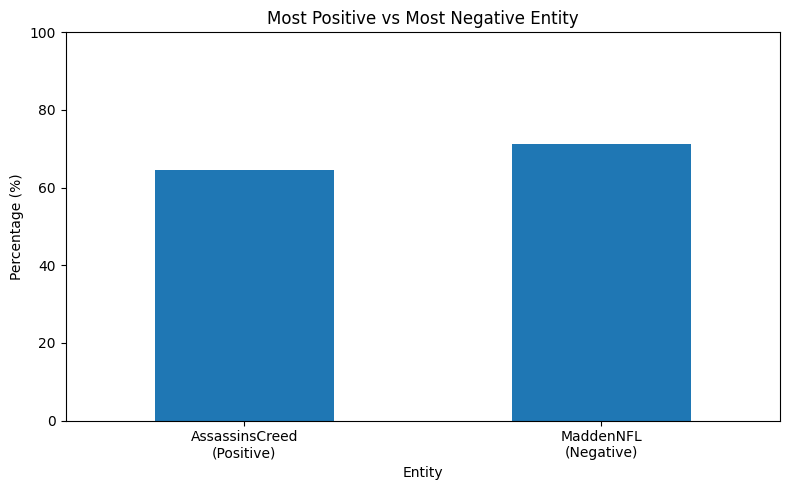

In [ ]:
results = pd.Series({
    "AssassinsCreed\n(Positive)": positive_percentage,
    "MaddenNFL\n(Negative)": negative_percentage
})

plt.figure(figsize=(8, 5))
results.plot(kind="bar")

plt.title("Most Positive vs Most Negative Entity")
plt.ylabel("Percentage (%)")
plt.xlabel("Entity")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud

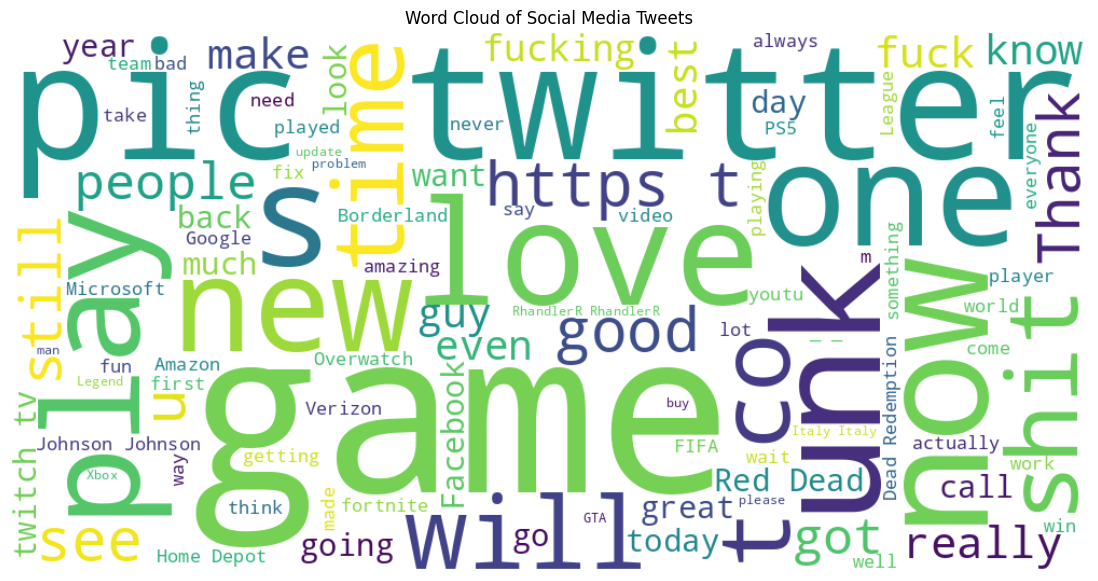

In [ ]:
text = " ".join(df["Text"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Social Media Tweets")
plt.show()

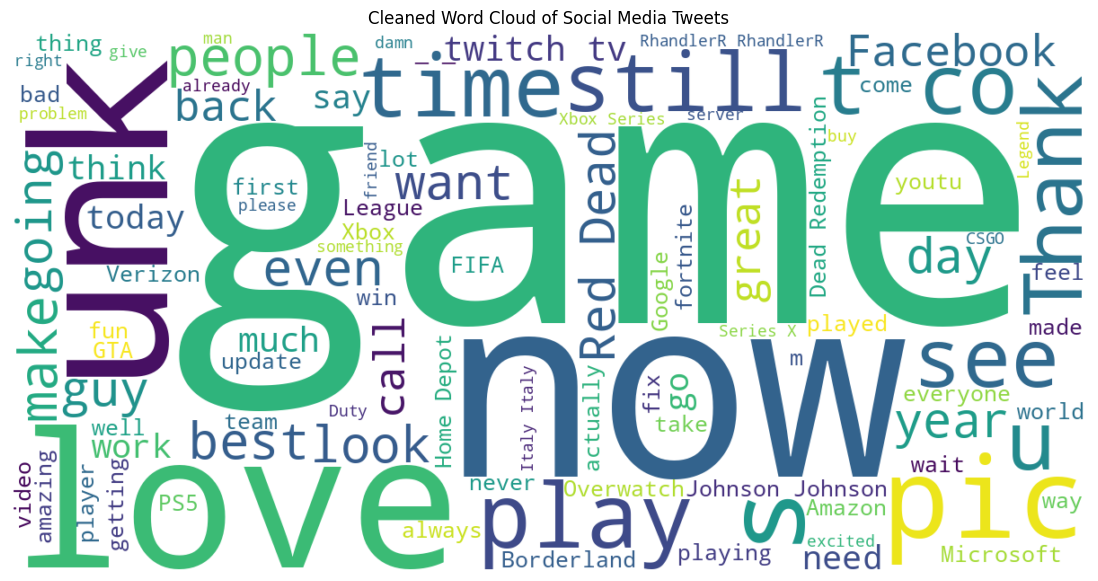

In [ ]:
from wordcloud import WordCloud, STOPWORDS

stop_words = set(STOPWORDS)

# Add common social-media words and unwanted terms
stop_words.update([
    "https", "http", "twitter", "tweet",
    "one", "like", "get", "got", "will",
    "really", "know", "good", "new",
    "fuck", "fucking", "shit"
])

text = " ".join(df["Text"].astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stop_words,
    max_words=100
).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Cleaned Word Cloud of Social Media Tweets")
plt.show()

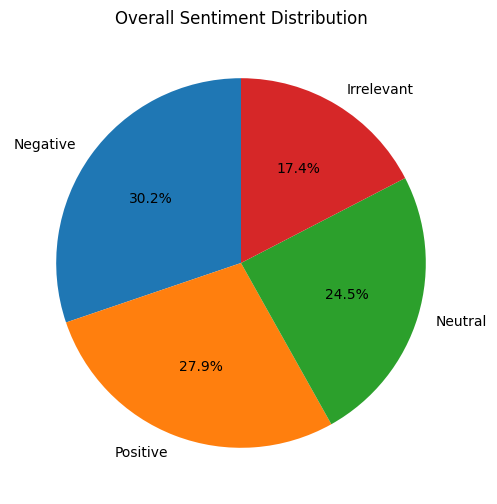

In [ ]:
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Sentiment Distribution")
plt.show()

**Conclusion**: The sentiment analysis shows that negative sentiment has the highest proportion at 30.2%, followed by positive sentiment at 27.9% and neutral sentiment at 24.5%. Irrelevant tweets account for 17.4% of the dataset. Overall, the data contains slightly more negative than positive opinions, indicating that users expressed somewhat more negative attitudes toward the entities/topics in the dataset.